In [1]:
# Core libraries
import os
import random
import json
import time

import numpy as np
import pandas as pd
import torch

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

[HAMI-core Msg(1506:139894140263744:libvgpu.c:839)]: Initializing.....
[HAMI-core Warn(1506:139894140263744:multiprocess_memory_limit.c:548)]: Kick dead proc 174
[HAMI-core Msg(1506:139894140263744:libvgpu.c:855)]: Initialized


In [2]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

free, total = torch.cuda.mem_get_info()

print(f"CUDA free : {free / 1024**3:.2f} GB")
print(f"CUDA total: {total / 1024**3:.2f} GB")

CUDA available: True
GPU: NVIDIA A100 80GB PCIe
CUDA free : 15.16 GB
CUDA total: 16.00 GB


In [4]:
x = torch.empty(
    (256, 1024, 1024),
    dtype=torch.float32,
    device="cuda"
)

print("1 GB CUDA allocation: SUCCESS")

del x
torch.cuda.empty_cache()

1 GB CUDA allocation: SUCCESS


In [5]:
# ============================================================
# Experiment configuration
# ============================================================

MODEL_NAME = "FacebookAI/xlm-roberta-base"

NUM_LABELS = 5
MAX_LENGTH = 128
BATCH_SIZE = 8
LEARNING_RATE = 2e-5
NUM_EPOCHS = 10
SEED = 42
EARLY_STOPPING_PATIENCE = 2
# Dataset paths relative to the classifier notebook folder
TRAIN_PATH = "../RUHSOLD_train.tsv"
VAL_PATH = "../RUHSOLD_validation.tsv"
TEST_PATH = "../RUHSOLD_test.tsv"

OUTPUT_DIR = "./outputs/xlm_roberta_baseline"


In [6]:
# ============================================================
# Load prepared RUHSOLD splits
# ============================================================

train_df = pd.read_csv(
    TRAIN_PATH,
    sep="\t",
    names=["tweet", "label"]
)

val_df = pd.read_csv(
    VAL_PATH,
    sep="\t",
    names=["tweet", "label"]
)

test_df = pd.read_csv(
    TEST_PATH,
    sep="\t",
    names=["tweet", "label"]
)

print(f"Training samples   : {len(train_df)}")
print(f"Validation samples : {len(val_df)}")
print(f"Testing samples    : {len(test_df)}")

Training samples   : 6408
Validation samples : 801
Testing samples    : 2003


In [7]:
# Confirm the prepared files contain the expected five labels.
expected_labels = {0, 1, 2, 3, 4}

assert set(train_df["label"].unique()) == expected_labels
assert set(val_df["label"].unique()) == expected_labels
assert set(test_df["label"].unique()) == expected_labels

assert train_df["tweet"].notna().all()
assert val_df["tweet"].notna().all()
assert test_df["tweet"].notna().all()

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [8]:
# ============================================================
# Reproducibility setup
# ============================================================

import os
import random
import numpy as np
import torch

def set_seed(seed: int) -> None:
    """
    Set random seeds across Python, NumPy, and PyTorch.

    This reduces variation between repeated runs. Exact reproducibility
    can still depend on the GPU, CUDA version, and installed libraries.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # Encourage deterministic CUDA behaviour where possible.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "GPU memory:",
        round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2),
        "GB"
    )

Device: cuda
GPU: NVIDIA A100 80GB PCIe
GPU memory: 16.0 GB


In [9]:
# ============================================================
# RUHSOLD label mappings
# ============================================================

id2label = {
    0: "Abusive/Offensive",
    1: "Normal",
    2: "Religious Hate",
    3: "Sexism",
    4: "Profane"
}

label2id = {label: idx for idx, label in id2label.items()}

print("Label mapping:")
for label_id, label_name in id2label.items():
    print(f"{label_id}: {label_name}")

Label mapping:
0: Abusive/Offensive
1: Normal
2: Religious Hate
3: Sexism
4: Profane


In [10]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer:", tokenizer.__class__.__name__)
print("Vocabulary size:", tokenizer.vocab_size)
print("Model maximum length:", tokenizer.model_max_length)

Tokenizer: XLMRobertaTokenizer
Vocabulary size: 250002
Model maximum length: 512


In [11]:
# ============================================================
# PyTorch dataset class for RUHSOLD
# ============================================================

from torch.utils.data import Dataset

class RUHSOLDDataset(Dataset):
    """
    PyTorch Dataset for the RUHSOLD classification task.

    Each item contains:
    - input_ids
    - attention_mask
    - label
    """

    def __init__(
        self,
        dataframe: pd.DataFrame,
        tokenizer,
        max_length: int
    ) -> None:
        """
        Store tweets, labels, tokenizer, and maximum sequence length.
        """
        self.tweets = dataframe["tweet"].astype(str).tolist()
        self.labels = dataframe["label"].astype(int).tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self) -> int:
        """
        Return the number of samples in the dataset.
        """
        return len(self.tweets)

    def __getitem__(self, index: int) -> dict:
        """
        Tokenize one tweet and return it with its label.
        """
        tweet = self.tweets[index]
        label = self.labels[index]

        encoded = self.tokenizer(
            tweet,
            truncation=True,
            max_length=self.max_length,
            padding=False
        )

        encoded["labels"] = label

        return encoded

In [12]:
# ============================================================
# Create train, validation, and test datasets
# ============================================================

train_dataset = RUHSOLDDataset(
    dataframe=train_df,
    tokenizer=tokenizer,
    max_length=MAX_LENGTH
)

val_dataset = RUHSOLDDataset(
    dataframe=val_df,
    tokenizer=tokenizer,
    max_length=MAX_LENGTH
)

test_dataset = RUHSOLDDataset(
    dataframe=test_df,
    tokenizer=tokenizer,
    max_length=MAX_LENGTH
)

print(f"Training dataset   : {len(train_dataset)}")
print(f"Validation dataset : {len(val_dataset)}")
print(f"Testing dataset    : {len(test_dataset)}")

Training dataset   : 6408
Validation dataset : 801
Testing dataset    : 2003


In [13]:


sample_tweets = [
    train_df.iloc[0]["tweet"],
    "tum bohat ache insan ho",
    "yeh bohat buri aur ghatiya baat hai"
]

for tweet in sample_tweets:
    tokens = tokenizer.tokenize(str(tweet))

    print("-" * 80)
    print("Tweet :", tweet)
    print("Tokens:", tokens)
    print("Number of tokens:", len(tokens))

--------------------------------------------------------------------------------
Tweet : kia howa hai aap ko allah bless and protect you  aameen
Tokens: ['▁kia', '▁how', 'a', '▁hai', '▁aap', '▁ko', '▁', 'allah', '▁bless', '▁and', '▁protect', '▁you', '▁a', 'ame', 'en']
Number of tokens: 15
--------------------------------------------------------------------------------
Tweet : tum bohat ache insan ho
Tokens: ['▁tum', '▁bohat', '▁a', 'che', '▁insan', '▁ho']
Number of tokens: 6
--------------------------------------------------------------------------------
Tweet : yeh bohat buri aur ghatiya baat hai
Tokens: ['▁yeh', '▁bohat', '▁', 'buri', '▁aur', '▁gha', 'tiya', '▁baat', '▁hai']
Number of tokens: 9


In [14]:
# ============================================================
# Dynamic batch padding
# ============================================================

from transformers import DataCollatorWithPadding

# Pad each batch only to the longest sequence within that batch.
# This is more memory-efficient than padding every tweet to MAX_LENGTH.
data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    return_tensors="pt"
)

In [15]:
# ============================================================
# Evaluation metrics
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)

def compute_metrics(eval_prediction):
    """
    Compute evaluation metrics from model logits and true labels.

    Macro averaging gives equal importance to all five classes,
    which is necessary because RUHSOLD is class-imbalanced.
    """
    logits, labels = eval_prediction
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)

    macro_precision, macro_recall, macro_f1, _ = (
        precision_recall_fscore_support(
            labels,
            predictions,
            average="macro",
            zero_division=0
        )
    )

    weighted_precision, weighted_recall, weighted_f1, _ = (
        precision_recall_fscore_support(
            labels,
            predictions,
            average="weighted",
            zero_division=0
        )
    )

    return {
        "accuracy": accuracy,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "weighted_precision": weighted_precision,
        "weighted_recall": weighted_recall,
        "weighted_f1": weighted_f1
    }

In [16]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id
)

print("Model:", model.__class__.__name__)
print("Number of labels:", model.config.num_labels)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: FacebookAI/xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model: XLMRobertaForSequenceClassification
Number of labels: 5


In [14]:
import accelerate
import transformers

print("Accelerate version :", accelerate.__version__)
print("Transformers version:", transformers.__version__)

Accelerate version : 1.14.0
Transformers version: 5.14.1


In [15]:
%pip install -U "accelerate>=1.1.0"

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [14]:




training_args = TrainingArguments(
    output_dir="./outputs/xlm_roberta_baseline",

    eval_strategy="epoch",
    logging_strategy="epoch",

    # Save only when validation Macro F1 improves.
    save_strategy="best",
    save_total_limit=1,
    save_only_model=True,

    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=NUM_EPOCHS,
    weight_decay=0.01,
    warmup_steps=240,

    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    seed=SEED,
    data_seed=SEED,

    bf16=torch.cuda.is_available(),
    fp16=False,

    report_to="none",
    disable_tqdm=False
)

[HAMI-core Msg(1004:139653081016128:multiprocess_memory_limit.c:455)]: Calling exit handler 1004


In [30]:

# ============================================================
# Create Trainer with EarlyStoppingCallback
# ============================================================



from transformers import Trainer, EarlyStoppingCallback

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    processing_class=tokenizer,

    # Stop when validation Macro F1 has not improved for
    # two consecutive epoch-level evaluations.
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=EARLY_STOPPING_PATIENCE,
            early_stopping_threshold=0.0
        )
    ]
)

print("Trainer with early stopping created successfully.")

Trainer with early stopping created successfully.


In [21]:
# ============================================================
# Train mBERT with a maximum of 10 epochs and early stopping
# ============================================================

import time

start_time = time.time()

train_result = trainer.train()

training_time_seconds = time.time() - start_time

print("\nTraining completed.")
print(f"Total training time: {training_time_seconds / 60:.2f} minutes")
print(f"Epoch reached: {trainer.state.epoch:.0f}")
print("Best checkpoint:", trainer.state.best_model_checkpoint)
print(f"Best validation Macro F1: {trainer.state.best_metric:.4f}")

Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
1,1.106767,0.773969,0.717853,0.545708,0.557180,0.548294,0.688041,0.717853,0.699696
2,0.699166,0.636062,0.785268,0.716963,0.726622,0.717519,0.782760,0.785268,0.779862
3,0.581421,0.674642,0.769039,0.681559,0.725999,0.701099,0.774966,0.769039,0.770761
4,0.485219,0.754863,0.785268,0.730437,0.708286,0.717221,0.788049,0.785268,0.785782


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Training completed.
Total training time: 2.85 minutes
Epoch reached: 4
Best checkpoint: ./outputs/xlm_roberta_baseline/checkpoint-1602
Best validation Macro F1: 0.7175


In [31]:
import os
import shutil

current_path = os.getcwd()
disk = shutil.disk_usage(current_path)

print("Current folder:", current_path)
print(f"Total disk space: {disk.total / 1024**3:.2f} GB")
print(f"Used disk space : {disk.used / 1024**3:.2f} GB")
print(f"Free disk space : {disk.free / 1024**3:.2f} GB")

Current folder: /home/jovyan/project work/data_analyssis/classifier
Total disk space: 24.52 GB
Used disk space : 21.94 GB
Free disk space : 2.56 GB


In [31]:
# ============================================================
# Extract epoch-level validation history
# ============================================================

import pandas as pd

history_df = pd.DataFrame(trainer.state.log_history)

validation_columns = [
    "epoch",
    "eval_loss",
    "eval_accuracy",
    "eval_macro_precision",
    "eval_macro_recall",
    "eval_macro_f1",
    "eval_weighted_precision",
    "eval_weighted_recall",
    "eval_weighted_f1"
]

validation_history = history_df.loc[
    history_df["eval_macro_f1"].notna(),
    validation_columns
].copy()

# Remove any repeated final-evaluation records.
validation_history = (
    validation_history
    .drop_duplicates(subset=["epoch"], keep="first")
    .sort_values("epoch")
    .reset_index(drop=True)
)

validation_history

,epoch,eval_loss,eval_accuracy,eval_macro_precision,eval_macro_recall,eval_macro_f1,eval_weighted_precision,eval_weighted_recall,eval_weighted_f1
0,1.0,0.773969,0.717853,0.545708,0.557180,0.548294,0.688041,0.717853,0.699696
1,2.0,0.636062,0.785268,0.716963,0.726622,0.717519,0.782760,0.785268,0.779862
2,3.0,0.674642,0.769039,0.681559,0.725999,0.701099,0.774966,0.769039,0.770761
3,4.0,0.754863,0.785268,0.730437,0.708286,0.717221,0.788049,0.785268,0.785782


In [32]:
# ============================================================
# Save validation history and best-run summary
# ============================================================

import os
import json

RESULTS_DIR = "./outputs/xlm_roberta_early_stopping"
os.makedirs(RESULTS_DIR, exist_ok=True)

validation_history.to_csv(
    os.path.join(RESULTS_DIR, "validation_history.csv"),
    index=False
)


best_epoch = int(
    validation_history.loc[
        validation_history["eval_macro_f1"].idxmax(),
        "epoch"
    ]
)

best_run_summary = {
    "model_name": MODEL_NAME,
    "maximum_epochs": NUM_EPOCHS,
    "epochs_completed": float(trainer.state.epoch),
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "best_epoch":best_epoch ,
    "best_checkpoint": trainer.state.best_model_checkpoint,
    "best_validation_macro_f1": float(trainer.state.best_metric),
    "training_time_minutes": float(training_time_seconds / 60)
}

with open(
    os.path.join(RESULTS_DIR, "best_run_summary.json"),
    "w",
    encoding="utf-8"
) as file:
    json.dump(best_run_summary, file, indent=4)

print("Validation history saved.")
print("Best-run summary saved.")

NameError: name 'validation_history' is not defined

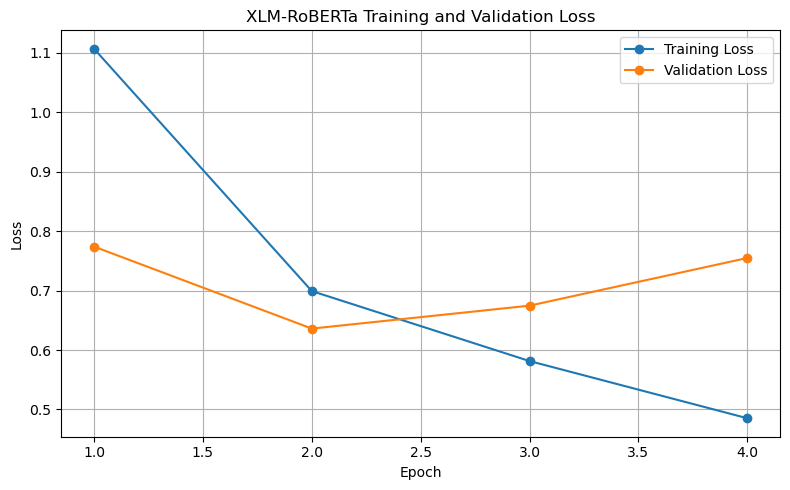

In [25]:
# ============================================================
# Plot training loss and validation loss
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# Convert the Trainer log history into a DataFrame.
history_df = pd.DataFrame(trainer.state.log_history)

# Training-loss rows contain the "loss" field.
train_loss_df = history_df[
    history_df["loss"].notna()
][["epoch", "loss"]].copy()

# Validation-loss rows contain the "eval_loss" field.
val_loss_df = history_df[
    history_df["eval_loss"].notna()
][["epoch", "eval_loss"]].copy()

# Remove repeated rows that can appear after final evaluation
# or best-checkpoint restoration.
train_loss_df = train_loss_df.drop_duplicates(
    subset=["epoch"],
    keep="first"
)

val_loss_df = val_loss_df.drop_duplicates(
    subset=["epoch"],
    keep="first"
)

# Plot both curves.
plt.figure(figsize=(8, 5))

plt.plot(
    train_loss_df["epoch"],
    train_loss_df["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    val_loss_df["epoch"],
    val_loss_df["eval_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("XLM-RoBERTa Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [26]:
# ============================================================
# Generate predictions on the validation set
# ============================================================

import numpy as np

# Predict on the validation set using the best checkpoint.
validation_predictions = trainer.predict(val_dataset)

# True labels
y_true = validation_predictions.label_ids

# Predicted labels
y_pred = np.argmax(validation_predictions.predictions, axis=1)

print("Validation samples:", len(y_true))

Validation samples: 801


In [27]:
# ============================================================
# Per-class classification report
# ============================================================

from sklearn.metrics import classification_report
import pandas as pd

target_names = [
    "Abusive/Offensive",
    "Normal",
    "Religious Hate",
    "Sexism",
    "Profane"
]

report = classification_report(
    y_true,
    y_pred,
    target_names=target_names,
    digits=4,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).transpose()

report_df

,precision,recall,f1-score,support
Abusive/Offensive,0.737931,0.557292,0.635015,192.000000
Normal,0.850325,0.915888,0.881890,428.000000
Religious Hate,0.687500,0.698413,0.692913,63.000000
Sexism,0.705882,0.716418,0.711111,67.000000
Profane,0.603175,0.745098,0.666667,51.000000
accuracy,0.785268,0.785268,0.785268,0.785268
macro avg,0.716963,0.726622,0.717519,801.000000
weighted avg,0.782760,0.785268,0.779862,801.000000


In [28]:
# ============================================================
# Validation Confusion Matrix
# ============================================================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

print(cm)

[[107  43   7  10  25]
 [ 19 392  12   5   0]
 [  5  10  44   4   0]
 [  9   9   1  48   0]
 [  5   7   0   1  38]]


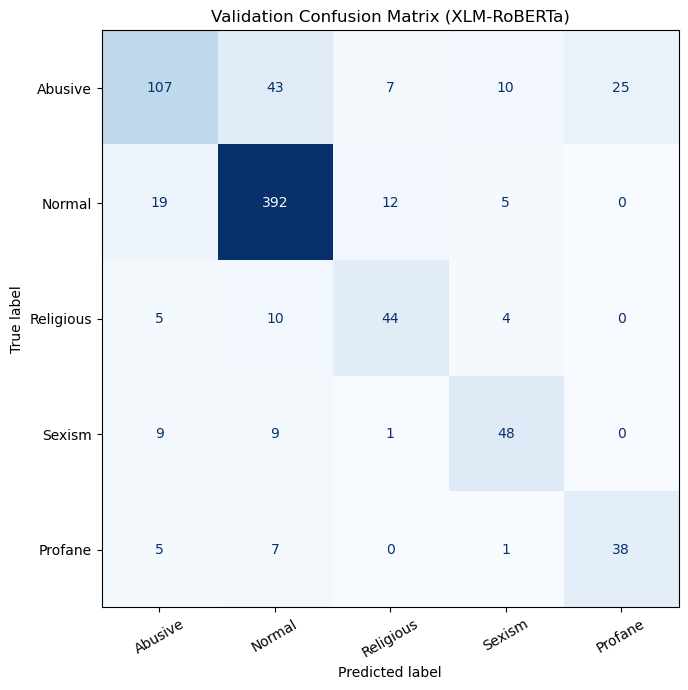

In [29]:
# ============================================================
# Plot Confusion Matrix
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

labels = [
    "Abusive",
    "Normal",
    "Religious",
    "Sexism",
    "Profane"
]

fig, ax = plt.subplots(figsize=(8,7))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot(
    cmap="Blues",
    values_format="d",
    ax=ax,
    colorbar=False
)

plt.title("Validation Confusion Matrix (XLM-RoBERTa)")
plt.xticks(rotation=30)
plt.tight_layout()

plt.show()

In [30]:
# ============================================================
# Save Confusion Matrix
# ============================================================

import pandas as pd

cm_df = pd.DataFrame(
    cm,
    index=labels,
    columns=labels
)

cm_df.to_csv(
    "./outputs/xlm_roberta_baseline/confusion_matrix_validation.csv"
)

print("Confusion matrix saved.")

Confusion matrix saved.


In [2]:
%pip install -q optuna

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
Note: you may need to restart the kernel to use updated packages.


In [33]:
# ============================================================
# XLM-R Hyperparameter Optimisation Configuration
# ============================================================

TUNING_OUTPUT_DIR = "./outputs/xlm_roberta_hyperparameter_search"

TUNING_MAX_EPOCHS = 6
TUNING_EARLY_STOPPING_PATIENCE = 2

# Keep search relatively small because of the dissertation deadline.
N_TRIALS = 12

print("Hyperparameter tuning configuration loaded.")
print("Number of Optuna trials:", N_TRIALS)

Hyperparameter tuning configuration loaded.
Number of Optuna trials: 12


In [34]:
# ============================================================
# Fresh XLM-R model for every hyperparameter trial
# ============================================================

from transformers import AutoModelForSequenceClassification

def model_init(trial=None):
    """
    Reinitialize XLM-R from the same pretrained checkpoint
    for every hyperparameter-search trial.
    """

    return AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=NUM_LABELS,
        id2label=id2label,
        label2id=label2id,
    )

print("model_init function created.")

model_init function created.


In [35]:
# ============================================================
# Optuna search space
# ============================================================

def hp_space(trial):
    """
    Hyperparameter search space for XLM-R fine-tuning.
    """

    return {
        "learning_rate": trial.suggest_float(
            "learning_rate",
            1e-5,
            5e-5,
            log=True,
        ),

        "per_device_train_batch_size": trial.suggest_categorical(
            "per_device_train_batch_size",
            [8, 16],
        ),

        "weight_decay": trial.suggest_float(
            "weight_decay",
            0.0,
            0.05,
        ),

        "warmup_ratio": trial.suggest_float(
            "warmup_ratio",
            0.0,
            0.10,
        ),
    }

print("Optuna search space created.")

Optuna search space created.


In [36]:
# ============================================================
# Hyperparameter optimisation objective
# ============================================================

def compute_objective(metrics):
    """
    Optimise validation Macro F1.
    """

    return metrics["eval_macro_f1"]

print("Objective: maximise validation Macro F1.")

Objective: maximise validation Macro F1.


In [37]:
# ============================================================
# Training arguments for hyperparameter search
# ============================================================

from transformers import TrainingArguments

tuning_training_args = TrainingArguments(
    output_dir=TUNING_OUTPUT_DIR,

    eval_strategy="epoch",
    logging_strategy="epoch",

    # Saving during HPO is not needed.
    save_strategy="no",

    # These are placeholders.
    # Optuna will overwrite the searched parameters.
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    weight_decay=0.01,
    warmup_ratio=0.05,

    num_train_epochs=TUNING_MAX_EPOCHS,

    metric_for_best_model="macro_f1",
    greater_is_better=True,

    seed=SEED,
    data_seed=SEED,

    bf16=torch.cuda.is_available(),
    fp16=False,

    report_to="none",
    disable_tqdm=False,
)

print("Tuning TrainingArguments created.")

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Tuning TrainingArguments created.


[HAMI-core Msg(1594:140314048845632:multiprocess_memory_limit.c:455)]: Calling exit handler 1594


In [38]:
# ============================================================
# Trainer for hyperparameter optimisation
# ============================================================

from transformers import Trainer, EarlyStoppingCallback

tuning_trainer = Trainer(
    model_init=model_init,
    args=tuning_training_args,

    train_dataset=train_dataset,
    eval_dataset=val_dataset,

    data_collator=data_collator,
    compute_metrics=compute_metrics,
    processing_class=tokenizer,

    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=TUNING_EARLY_STOPPING_PATIENCE,
            early_stopping_threshold=0.0,
        )
    ],
)

print("Hyperparameter-search Trainer created.")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: FacebookAI/xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Hyperparameter-search Trainer created.


In [39]:
# ============================================================
# Run Optuna hyperparameter search
# ============================================================

import time

tuning_start_time = time.time()

best_run = tuning_trainer.hyperparameter_search(
    direction="maximize",
    backend="optuna",
    hp_space=hp_space,
    compute_objective=compute_objective,
    n_trials=N_TRIALS,

    # Helps clean unused trial objects from memory.
    gc_after_trial=True,
)

tuning_time_seconds = (
    time.time() - tuning_start_time
)

print("\nHyperparameter search completed.")

print(
    f"Total tuning time: "
    f"{tuning_time_seconds / 60:.2f} minutes"
)

print("\nBest objective:")
print(best_run.objective)

print("\nBest hyperparameters:")
for key, value in best_run.hyperparameters.items():
    print(f"{key}: {value}")

[I 2026-08-12 19:01:43,555] A new study created in memory with name: no-name-68f7050b-1a8a-4003-b131-83a2b2178a93


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: FacebookAI/xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] Using EarlyStoppingCallback without load_best_model_at_end=True. Onc

Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
1,1.134336,0.808021,0.687890,0.598370,0.494644,0.496085,0.689562,0.687890,0.668391
2,0.718059,0.673971,0.765293,0.692840,0.699069,0.694785,0.765693,0.765293,0.765066
3,0.560711,0.696579,0.770287,0.692110,0.721075,0.705518,0.779159,0.770287,0.773678
4,0.464278,0.779283,0.780275,0.710698,0.730262,0.716731,0.792456,0.780275,0.784167
5,0.375061,0.929667,0.795256,0.718459,0.723440,0.719818,0.797227,0.795256,0.795754
6,0.287560,0.966880,0.805243,0.719809,0.724284,0.721385,0.804224,0.805243,0.804229


[I 2026-08-12 19:06:38,442] Trial 0 finished with value: 0.7213850998925231 and parameters: {'learning_rate': 3.780000695069206e-05, 'per_device_train_batch_size': 8, 'weight_decay': 0.012657362458542855, 'warmup_ratio': 0.04645358520869273}. Best is trial 0 with value: 0.7213850998925231.


...

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: FacebookAI/xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] Using EarlyStoppingCallback without load_best_model_at_end=True. Onc

Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
1,1.128892,0.747736,0.724095,0.540760,0.540401,0.537933,0.682701,0.724095,0.701037
2,0.682430,0.616153,0.790262,0.725252,0.711886,0.717491,0.785640,0.790262,0.786737
3,0.549017,0.661057,0.779026,0.696964,0.730958,0.711866,0.791847,0.779026,0.783739
4,0.434598,0.619418,0.800250,0.722974,0.750067,0.732954,0.802757,0.800250,0.799234


[I 2026-08-12 19:24:12,176] Trial 11 pruned. 



Hyperparameter search completed.
Total tuning time: 22.48 minutes

Best objective:
0.7522263586528213

Best hyperparameters:
learning_rate: 2.881129057462248e-05
per_device_train_batch_size: 16
weight_decay: 0.03348739395854274
warmup_ratio: 0.03756172525242821


In [18]:
# ============================================================
# Final tuned XLM-R configuration
# Best hyperparameters found by Optuna
# ============================================================

BEST_LEARNING_RATE = 2.881129057462248e-05
BEST_BATCH_SIZE = 16
BEST_WEIGHT_DECAY = 0.03348739395854274
BEST_WARMUP_RATIO = 0.03756172525242821

FINAL_MAX_EPOCHS = 10
FINAL_EARLY_STOPPING_PATIENCE = 2

FINAL_OUTPUT_DIR = "./outputs/xlm_roberta_tuned"
FINAL_RESULTS_DIR = "./outputs/xlm_roberta_tuned_results"

print("Final tuned XLM-R configuration loaded.")

print(f"Learning rate : {BEST_LEARNING_RATE}")
print(f"Batch size    : {BEST_BATCH_SIZE}")
print(f"Weight decay  : {BEST_WEIGHT_DECAY}")
print(f"Warmup ratio  : {BEST_WARMUP_RATIO}")

Final tuned XLM-R configuration loaded.
Learning rate : 2.881129057462248e-05
Batch size    : 16
Weight decay  : 0.03348739395854274
Warmup ratio  : 0.03756172525242821


In [17]:
# ============================================================
# Load fresh pretrained XLM-R for final tuned run
# ============================================================

from transformers import AutoModelForSequenceClassification

final_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id
)

print("Fresh pretrained XLM-R model loaded.")
print("Model:", final_model.__class__.__name__)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: FacebookAI/xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fresh pretrained XLM-R model loaded.
Model: XLMRobertaForSequenceClassification


In [19]:
# ============================================================
# Final tuned XLM-R training arguments
# ============================================================

from transformers import TrainingArguments
import torch
import math


# ============================================================
# Convert frozen Optuna warmup ratio to warmup steps
#
# The current Transformers version does not accept
# `warmup_ratio` in TrainingArguments.
#
# The Optuna-selected ratio itself is NOT changed.
# ============================================================

ORIGINAL_TRAIN_SIZE = len(
    train_dataset
)

assert ORIGINAL_TRAIN_SIZE == 6408


STEPS_PER_EPOCH = math.ceil(
    ORIGINAL_TRAIN_SIZE
    / BEST_BATCH_SIZE
)


MAX_TRAINING_STEPS = (
    STEPS_PER_EPOCH
    * FINAL_MAX_EPOCHS
)


BEST_WARMUP_STEPS = math.ceil(
    MAX_TRAINING_STEPS
    * BEST_WARMUP_RATIO
)


print(
    "Original training samples:",
    ORIGINAL_TRAIN_SIZE
)

print(
    "Steps per epoch:",
    STEPS_PER_EPOCH
)

print(
    "Maximum training steps:",
    MAX_TRAINING_STEPS
)

print(
    "Frozen Optuna warmup ratio:",
    BEST_WARMUP_RATIO
)

print(
    "Equivalent warmup steps:",
    BEST_WARMUP_STEPS
)


assert STEPS_PER_EPOCH == 401
assert MAX_TRAINING_STEPS == 4010
assert BEST_WARMUP_STEPS == 151


# ============================================================
# Final TrainingArguments
# ============================================================

final_training_args = TrainingArguments(

    output_dir=FINAL_OUTPUT_DIR,

    # --------------------------------------------------------
    # Evaluate / log once per epoch
    # --------------------------------------------------------

    eval_strategy="epoch",

    logging_strategy="epoch",

    # --------------------------------------------------------
    # Save only when validation Macro F1 improves
    # --------------------------------------------------------

    save_strategy="best",

    save_total_limit=1,

    # Do not save optimizer/scheduler states.
    save_only_model=True,

    # --------------------------------------------------------
    # Frozen Optuna-selected hyperparameters
    # --------------------------------------------------------

    learning_rate=(
        BEST_LEARNING_RATE
    ),

    per_device_train_batch_size=(
        BEST_BATCH_SIZE
    ),

    per_device_eval_batch_size=(
        BEST_BATCH_SIZE
    ),

    weight_decay=(
        BEST_WEIGHT_DECAY
    ),

    # SAME Optuna-selected warmup schedule,
    # expressed as steps for this Transformers version.
    warmup_steps=(
        BEST_WARMUP_STEPS
    ),

    # --------------------------------------------------------
    # Maximum training duration
    # --------------------------------------------------------

    num_train_epochs=(
        FINAL_MAX_EPOCHS
    ),

    # --------------------------------------------------------
    # Restore checkpoint with highest validation Macro F1
    # --------------------------------------------------------

    load_best_model_at_end=True,

    metric_for_best_model=(
        "macro_f1"
    ),

    greater_is_better=True,

    # --------------------------------------------------------
    # Reproducibility
    # --------------------------------------------------------

    seed=SEED,

    data_seed=SEED,

    # --------------------------------------------------------
    # Mixed precision
    # --------------------------------------------------------

    bf16=torch.cuda.is_available(),

    fp16=False,

    report_to="none",

    disable_tqdm=False,
)


print(
    "\nFinal tuned TrainingArguments created successfully."
)

Original training samples: 6408
Steps per epoch: 401
Maximum training steps: 4010
Frozen Optuna warmup ratio: 0.03756172525242821
Equivalent warmup steps: 151

Final tuned TrainingArguments created successfully.


[HAMI-core Msg(1749:140217960728384:multiprocess_memory_limit.c:455)]: Calling exit handler 1749


In [20]:
# ============================================================
# Create final tuned XLM-R Trainer
# ============================================================

from transformers import Trainer, EarlyStoppingCallback

final_trainer = Trainer(
    model=final_model,
    args=final_training_args,

    train_dataset=train_dataset,
    eval_dataset=val_dataset,

    data_collator=data_collator,
    compute_metrics=compute_metrics,
    processing_class=tokenizer,

    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=FINAL_EARLY_STOPPING_PATIENCE,
            early_stopping_threshold=0.0
        )
    ]
)

print("Final tuned XLM-R Trainer created successfully.")

[HAMI-core ERROR (pid:174 thread=139894690958656 allocator.c:121)]: cuMemoryAllocate failed res=2
[HAMI-core ERROR (pid:174 thread=139894690958656 allocator.c:121)]: cuMemoryAllocate failed res=2


OutOfMemoryError: CUDA out of memory. Tried to allocate 20.00 MiB. GPU 0 has a total capacity of 16.00 GiB of which 13.16 GiB is free. Process 69754 has 68.35 GiB memory in use. Process 144722 has 3.54 GiB memory in use. Process 75163 has 4.14 GiB memory in use. Process 251211 has 534.00 MiB memory in use. Process 251220 has 2.49 GiB memory in use. Of the allocated memory 1.97 GiB is allocated by PyTorch, and 15.43 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [21]:
# ============================================================
# Train final tuned XLM-R
# ============================================================

import time

final_start_time = time.time()

final_train_result = final_trainer.train()

final_training_time_seconds = (
    time.time() - final_start_time
)

print("\nFinal tuned training completed.")
print(
    f"Training time: "
    f"{final_training_time_seconds / 60:.2f} minutes"
)
print(
    f"Epoch reached: "
    f"{final_trainer.state.epoch:.0f}"
)
print(
    "Best checkpoint:",
    final_trainer.state.best_model_checkpoint
)
print(
    f"Best validation Macro F1: "
    f"{final_trainer.state.best_metric:.4f}"
)

Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
1,1.154575,0.756372,0.724095,0.531424,0.558569,0.542572,0.689185,0.724095,0.704252
2,0.727964,0.718407,0.730337,0.534985,0.564774,0.545921,0.669709,0.730337,0.694374
3,0.620635,0.650341,0.780275,0.699298,0.735634,0.715616,0.787316,0.780275,0.782942
4,0.475034,0.697950,0.765293,0.680866,0.655625,0.665580,0.759013,0.765293,0.761076
5,0.385570,0.676994,0.791511,0.721541,0.719678,0.714369,0.798063,0.791511,0.792111


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Final tuned training completed.
Training time: 2.17 minutes
Epoch reached: 5
Best checkpoint: ./outputs/xlm_roberta_tuned/checkpoint-1203
Best validation Macro F1: 0.7156


In [22]:
# ============================================================
# Extract final tuned validation history
# ============================================================

import pandas as pd

final_history_df = pd.DataFrame(
    final_trainer.state.log_history
)

print("Number of log records:", len(final_history_df))

if final_history_df.empty:
    raise RuntimeError(
        "Trainer log history is empty. "
        "Make sure final_trainer.train() completed successfully first."
    )

final_validation_columns = [
    "epoch",
    "eval_loss",
    "eval_accuracy",
    "eval_macro_precision",
    "eval_macro_recall",
    "eval_macro_f1",
    "eval_weighted_precision",
    "eval_weighted_recall",
    "eval_weighted_f1"
]

if "eval_macro_f1" not in final_history_df.columns:
    print("Available log columns:")
    print(final_history_df.columns.tolist())

    raise RuntimeError(
        "No validation Macro F1 was found in the Trainer history."
    )

final_validation_history = (
    final_history_df[
        final_history_df["eval_macro_f1"].notna()
    ][final_validation_columns]
    .drop_duplicates(
        subset=["epoch"],
        keep="first"
    )
    .sort_values("epoch")
    .reset_index(drop=True)
)

display(final_validation_history)

Number of log records: 11


,epoch,eval_loss,eval_accuracy,eval_macro_precision,eval_macro_recall,eval_macro_f1,eval_weighted_precision,eval_weighted_recall,eval_weighted_f1
0,1.0,0.756372,0.724095,0.531424,0.558569,0.542572,0.689185,0.724095,0.704252
1,2.0,0.718407,0.730337,0.534985,0.564774,0.545921,0.669709,0.730337,0.694374
2,3.0,0.650341,0.780275,0.699298,0.735634,0.715616,0.787316,0.780275,0.782942
3,4.0,0.697950,0.765293,0.680866,0.655625,0.665580,0.759013,0.765293,0.761076
4,5.0,0.676994,0.791511,0.721541,0.719678,0.714369,0.798063,0.791511,0.792111


In [23]:
# ============================================================
# Evaluate best tuned XLM-R checkpoint on validation set
# ============================================================

final_validation_metrics = final_trainer.evaluate(
    eval_dataset=val_dataset
)

print("FINAL TUNED XLM-R VALIDATION METRICS")
print("=" * 50)

for key, value in final_validation_metrics.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")

Training Loss,Validation Loss,Epoch,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
0.385570,0.650341,5,0.780275,0.699298,0.735634,0.715616,0.787316,0.780275,0.782942


FINAL TUNED XLM-R VALIDATION METRICS
eval_loss: 0.6503
eval_accuracy: 0.7803
eval_macro_precision: 0.6993
eval_macro_recall: 0.7356
eval_macro_f1: 0.7156
eval_weighted_precision: 0.7873
eval_weighted_recall: 0.7803
eval_weighted_f1: 0.7829


In [24]:
# ============================================================
# Final tuned XLM-R per-class validation performance
# ============================================================

import numpy as np
import pandas as pd

from sklearn.metrics import classification_report

final_validation_predictions = final_trainer.predict(
    val_dataset
)

final_y_true = final_validation_predictions.label_ids

final_y_pred = np.argmax(
    final_validation_predictions.predictions,
    axis=1
)

target_names = [
    "Abusive/Offensive",
    "Normal",
    "Religious Hate",
    "Sexism",
    "Profane"
]

final_report = classification_report(
    final_y_true,
    final_y_pred,
    target_names=target_names,
    digits=4,
    output_dict=True,
    zero_division=0
)

final_report_df = pd.DataFrame(
    final_report
).transpose()

display(final_report_df)

,precision,recall,f1-score,support
Abusive/Offensive,0.661376,0.651042,0.656168,192.000000
Normal,0.899756,0.859813,0.879331,428.000000
Religious Hate,0.681818,0.714286,0.697674,63.000000
Sexism,0.729730,0.805970,0.765957,67.000000
Profane,0.523810,0.647059,0.578947,51.000000
accuracy,0.780275,0.780275,0.780275,0.780275
macro avg,0.699298,0.735634,0.715616,801.000000
weighted avg,0.787316,0.780275,0.782942,801.000000


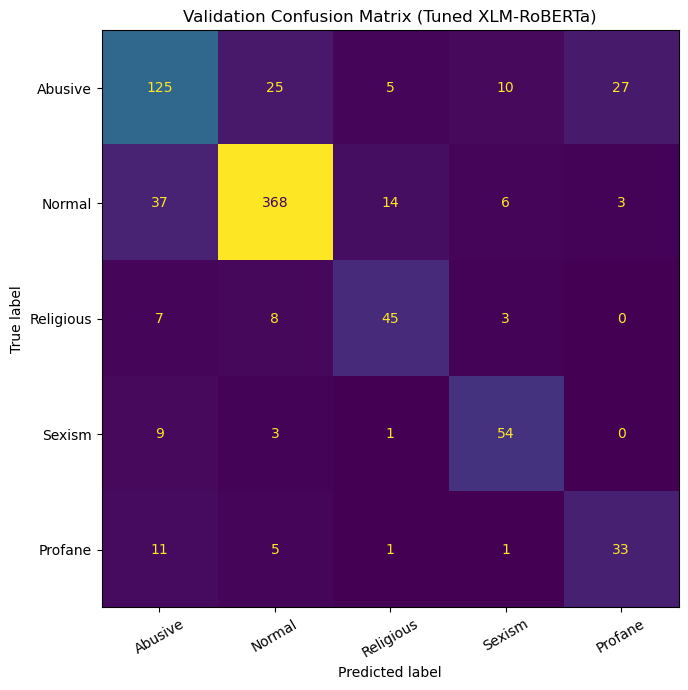


Confusion matrix:
[[125  25   5  10  27]
 [ 37 368  14   6   3]
 [  7   8  45   3   0]
 [  9   3   1  54   0]
 [ 11   5   1   1  33]]


In [25]:
# ============================================================
# Final tuned XLM-R validation confusion matrix
# ============================================================

import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

cm_tuned = confusion_matrix(
    final_y_true,
    final_y_pred,
    labels=[0, 1, 2, 3, 4]
)

display_labels = [
    "Abusive",
    "Normal",
    "Religious",
    "Sexism",
    "Profane"
]

fig, ax = plt.subplots(figsize=(8, 7))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_tuned,
    display_labels=display_labels
)

disp.plot(
    values_format="d",
    ax=ax,
    colorbar=False
)

plt.title(
    "Validation Confusion Matrix "
    "(Tuned XLM-RoBERTa)"
)

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print("\nConfusion matrix:")
print(cm_tuned)

In [26]:
# ============================================================
# Baseline vs tuned XLM-R comparison
# ============================================================

BASELINE_MACRO_F1 = 0.717519
BASELINE_ACCURACY = 0.785268

tuned_macro_f1 = final_validation_metrics[
    "eval_macro_f1"
]

tuned_accuracy = final_validation_metrics[
    "eval_accuracy"
]

macro_f1_gain = (
    tuned_macro_f1 - BASELINE_MACRO_F1
)

accuracy_gain = (
    tuned_accuracy - BASELINE_ACCURACY
)

print("XLM-R BASELINE VS TUNED")
print("=" * 45)

print(
    f"Baseline Macro F1 : "
    f"{BASELINE_MACRO_F1:.4f}"
)
print(
    f"Tuned Macro F1    : "
    f"{tuned_macro_f1:.4f}"
)
print(
    f"Macro F1 gain     : "
    f"{macro_f1_gain:+.4f} "
    f"({macro_f1_gain * 100:+.2f} percentage points)"
)

print()

print(
    f"Baseline Accuracy : "
    f"{BASELINE_ACCURACY:.4f}"
)
print(
    f"Tuned Accuracy    : "
    f"{tuned_accuracy:.4f}"
)
print(
    f"Accuracy gain     : "
    f"{accuracy_gain:+.4f} "
    f"({accuracy_gain * 100:+.2f} percentage points)"
)

XLM-R BASELINE VS TUNED
Baseline Macro F1 : 0.7175
Tuned Macro F1    : 0.7156
Macro F1 gain     : -0.0019 (-0.19 percentage points)

Baseline Accuracy : 0.7853
Tuned Accuracy    : 0.7803
Accuracy gain     : -0.0050 (-0.50 percentage points)


In [27]:
# ============================================================
# Load frozen synthetic QC validation set
# ============================================================

from pathlib import Path
import pandas as pd

QC_DIR = Path(
    "/home/jovyan/project work/data_analyssis/fine tuning/outputs/synthetic_generation/judge_validation"
)

QC_INPUT_PATH = QC_DIR / "judge_validation_final_input.csv"
QC_REFERENCE_PATH = QC_DIR / "judge_validation_final_reference.csv"

qc_input_df = pd.read_csv(QC_INPUT_PATH)
qc_reference_df = pd.read_csv(QC_REFERENCE_PATH)

print("QC input shape:", qc_input_df.shape)
print("QC reference shape:", qc_reference_df.shape)

print("\nInput columns:")
print(qc_input_df.columns.tolist())

print("\nReference columns:")
print(qc_reference_df.columns.tolist())

QC input shape: (80, 4)
QC reference shape: (80, 6)

Input columns:
['candidate_id', 'target_class_id', 'target_class', 'generated_text']

Reference columns:
['candidate_id', 'target_class_id', 'target_class', 'generated_text', 'human_decision', 'round']


In [28]:
# ============================================================
# Prepare synthetic QC samples for XLM-R
# ============================================================

qc_classifier_df = pd.DataFrame({
    "tweet": qc_input_df["generated_text"].astype(str),
    "label": qc_input_df["target_class_id"].astype(int),
})

qc_dataset = RUHSOLDDataset(
    dataframe=qc_classifier_df,
    tokenizer=tokenizer,
    max_length=MAX_LENGTH
)

print("QC dataset samples:", len(qc_dataset))

QC dataset samples: 80


In [29]:
# ============================================================
# Tuned XLM-R label-consistency predictions
# ============================================================

import numpy as np

qc_predictions = final_trainer.predict(
    qc_dataset
)

xlmr_pred_ids = np.argmax(
    qc_predictions.predictions,
    axis=1
)

xlmr_results_df = qc_input_df.copy()

xlmr_results_df["xlmr_predicted_class_id"] = (
    xlmr_pred_ids
)

xlmr_results_df["xlmr_predicted_class"] = (
    xlmr_results_df["xlmr_predicted_class_id"]
    .map(id2label)
)

xlmr_results_df["xlmr_decision"] = np.where(
    xlmr_results_df["xlmr_predicted_class_id"]
    == xlmr_results_df["target_class_id"],
    "Accept",
    "Reject"
)

print("XLM-R QC decisions:")
print(
    xlmr_results_df["xlmr_decision"]
    .value_counts()
)

display(
    xlmr_results_df[
        [
            "candidate_id",
            "target_class",
            "generated_text",
            "xlmr_predicted_class",
            "xlmr_decision",
        ]
    ].head(10)
)

XLM-R QC decisions:
xlmr_decision
Reject    45
Accept    35
Name: count, dtype: int64


,candidate_id,target_class,generated_text,xlmr_predicted_class,xlmr_decision
0,religious_high_precision_v1_0319,Religious Hate,o jb bnda bnda hua kis ko pta hi nahi,Normal,Reject
1,abusive_original_demo_v1_0100,Abusive/Offensive,saala lanti kuttay ki nasal,Abusive/Offensive,Accept
2,religious_high_precision_v1_0317,Religious Hate,agr apnay mullo k mujeed se pehly munafikat kr...,Abusive/Offensive,Reject
3,round2_religious_high_precision_v2_0616,Religious Hate,tum logon ne kaha tha k jb humne tera pichwaar...,Normal,Reject
4,round2_abusive_original_demo_v2_0916,Abusive/Offensive,yeh kya bhenchod,Profane,Reject
5,religious_high_precision_v1_0304,Religious Hate,tum logon ko bhi munafiqat se koi nahi pata,Abusive/Offensive,Reject
6,abusive_original_demo_v1_0101,Abusive/Offensive,laanat apne ghar per jo ek sath aik larki k au...,Abusive/Offensive,Accept
7,profane_original_demo_v1_0710,Profane,ye pata nahi kya gandu mera dost hai yaar,Abusive/Offensive,Reject
8,abusive_original_demo_v1_0106,Abusive/Offensive,ye logon ne koi wafa nhi kiya kisi ke liye bhe...,Profane,Reject
9,round2_abusive_original_demo_v2_0910,Abusive/Offensive,gashti ko bachy,Sexism,Reject


In [30]:
# ============================================================
# XLM-R vs human QC agreement
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score,
    confusion_matrix,
    classification_report,
)

xlmr_eval_df = xlmr_results_df.merge(
    qc_reference_df[
        [
            "candidate_id",
            "human_decision",
        ]
    ],
    on="candidate_id",
    how="inner",
    validate="one_to_one",
)

y_true = xlmr_eval_df["human_decision"]
y_pred = xlmr_eval_df["xlmr_decision"]

accuracy = accuracy_score(
    y_true,
    y_pred
)

accept_precision = precision_score(
    y_true,
    y_pred,
    pos_label="Accept",
    zero_division=0
)

accept_recall = recall_score(
    y_true,
    y_pred,
    pos_label="Accept",
    zero_division=0
)

accept_f1 = f1_score(
    y_true,
    y_pred,
    pos_label="Accept",
    zero_division=0
)

macro_f1 = f1_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

kappa = cohen_kappa_score(
    y_true,
    y_pred
)

print("=" * 55)
print("TUNED XLM-R VS HUMAN QC")
print("=" * 55)

print(f"Samples evaluated:   {len(xlmr_eval_df)}")
print(f"Accuracy:            {accuracy:.4f}")
print(f"Accept precision:    {accept_precision:.4f}")
print(f"Accept recall:       {accept_recall:.4f}")
print(f"Accept F1:           {accept_f1:.4f}")
print(f"Macro F1:            {macro_f1:.4f}")
print(f"Cohen's kappa:       {kappa:.4f}")

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=["Reject", "Accept"]
)

cm_df = pd.DataFrame(
    cm,
    index=[
        "Human Reject",
        "Human Accept",
    ],
    columns=[
        "XLM-R Reject",
        "XLM-R Accept",
    ]
)

print("\nConfusion matrix:")
display(cm_df)

print("\nClassification report:")

report = classification_report(
    y_true,
    y_pred,
    labels=["Accept", "Reject"],
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(
    report
).transpose()

display(report_df.round(4))

TUNED XLM-R VS HUMAN QC
Samples evaluated:   80
Accuracy:            0.6125
Accept precision:    0.6286
Accept recall:       0.5500
Accept F1:           0.5867
Macro F1:            0.6110
Cohen's kappa:       0.2250

Confusion matrix:


,XLM-R Reject,XLM-R Accept
Human Reject,27,13
Human Accept,18,22



Classification report:


,precision,recall,f1-score,support
Accept,0.6286,0.5500,0.5867,40.0000
Reject,0.6000,0.6750,0.6353,40.0000
accuracy,0.6125,0.6125,0.6125,0.6125
macro avg,0.6143,0.6125,0.6110,80.0000
weighted avg,0.6143,0.6125,0.6110,80.0000


In [31]:
# ============================================================
# Class-wise XLM-R vs human QC performance
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score
)

class_results = []

for target_class, group in xlmr_eval_df.groupby("target_class"):

    y_true_class = group["human_decision"]
    y_pred_class = group["xlmr_decision"]

    class_results.append({
        "target_class": target_class,
        "n": len(group),

        "accuracy": accuracy_score(
            y_true_class,
            y_pred_class
        ),

        "accept_precision": precision_score(
            y_true_class,
            y_pred_class,
            pos_label="Accept",
            zero_division=0
        ),

        "accept_recall": recall_score(
            y_true_class,
            y_pred_class,
            pos_label="Accept",
            zero_division=0
        ),

        "accept_f1": f1_score(
            y_true_class,
            y_pred_class,
            pos_label="Accept",
            zero_division=0
        ),

        "cohen_kappa": cohen_kappa_score(
            y_true_class,
            y_pred_class
        )
    })

class_results_df = pd.DataFrame(class_results)

display(
    class_results_df.round(4)
)

,target_class,n,accuracy,accept_precision,accept_recall,accept_f1,cohen_kappa
0,Abusive/Offensive,20,0.70,0.7500,0.6,0.6667,0.4
1,Profane,20,0.65,0.6364,0.7,0.6667,0.3
2,Religious Hate,20,0.55,0.5714,0.4,0.4706,0.1
3,Sexism,20,0.55,0.5556,0.5,0.5263,0.1


In [32]:
# ============================================================
# Inspect false accepts
# Human = Reject, XLM-R = Accept
# ============================================================

false_accepts_df = xlmr_eval_df[
    (xlmr_eval_df["human_decision"] == "Reject") &
    (xlmr_eval_df["xlmr_decision"] == "Accept")
].copy()

print("Number of false accepts:", len(false_accepts_df))

display(
    false_accepts_df[
        [
            "candidate_id",
            "target_class",
            "generated_text",
            "xlmr_predicted_class",
            "human_decision",
            "xlmr_decision"
        ]
    ]
)

Number of false accepts: 13


,candidate_id,target_class,generated_text,xlmr_predicted_class,human_decision,xlmr_decision
6,abusive_original_demo_v1_0101,Abusive/Offensive,laanat apne ghar per jo ek sath aik larki k au...,Abusive/Offensive,Reject,Accept
18,round2_sexism_high_precision_v2_0716,Sexism,ye fake hai iski maa ko chut randi sali,Sexism,Reject,Accept
24,religious_zero_shot_v1_0325,Religious Hate,hahaha halala ka bacha kya pta chl jata ha ye ...,Religious Hate,Reject,Accept
29,religious_zero_shot_v1_0328,Religious Hate,chalo ye kya bat hai bajwa tere jesy yahoodi a...,Religious Hate,Reject,Accept
30,sexism_original_demo_v1_0524,Sexism,teri maa ki phudi maine pakistani saali ke sat...,Sexism,Reject,Accept
31,round2_profane_original_demo_v2_0814,Profane,rt : bc aik din kabhi tere saamne dekh raha th...,Profane,Reject,Accept
39,abusive_original_demo_v1_0103,Abusive/Offensive,chutiye ghatya ptm k charsi ho gaye,Abusive/Offensive,Reject,Accept
47,religious_zero_shot_v1_0336,Religious Hate,yahoodi sazish ki hai,Religious Hate,Reject,Accept
51,profane_original_demo_v1_0716,Profane,psl huwa bc tera ghar mein,Profane,Reject,Accept
63,profane_original_demo_v1_0714,Profane,bhenchod jab tera number dekhun to aesa ho hi ...,Profane,Reject,Accept


In [33]:
print(qc_reference_df.columns.tolist())

display(qc_reference_df.head())

['candidate_id', 'target_class_id', 'target_class', 'generated_text', 'human_decision', 'round']


,candidate_id,target_class_id,target_class,generated_text,human_decision,round
0,religious_high_precision_v1_0319,2,Religious Hate,o jb bnda bnda hua kis ko pta hi nahi,Reject,Round 1
1,abusive_original_demo_v1_0100,0,Abusive/Offensive,saala lanti kuttay ki nasal,Accept,Round 1
2,religious_high_precision_v1_0317,2,Religious Hate,agr apnay mullo k mujeed se pehly munafikat kr...,Accept,Round 1
3,round2_religious_high_precision_v2_0616,2,Religious Hate,tum logon ne kaha tha k jb humne tera pichwaar...,Reject,Round 2
4,round2_abusive_original_demo_v2_0916,0,Abusive/Offensive,yeh kya bhenchod,Reject,Round 2


In [20]:
# --------------------------------------------------------
# EXACT SAME frozen tuned hyperparameters
# as augmented experiment
# --------------------------------------------------------

training_args = TrainingArguments(

    output_dir=str(
        seed_output_dir
    ),

    # ----------------------------------------------------
    # Evaluation / logging
    # ----------------------------------------------------

    eval_strategy="epoch",

    logging_strategy="epoch",

    # ----------------------------------------------------
    # Checkpointing
    # ----------------------------------------------------

    save_strategy="best",

    save_total_limit=1,

    save_only_model=True,

    # ----------------------------------------------------
    # Frozen Optuna-selected hyperparameters
    # ----------------------------------------------------

    learning_rate=(
        BEST_LEARNING_RATE
    ),

    per_device_train_batch_size=(
        BEST_BATCH_SIZE
    ),

    per_device_eval_batch_size=(
        BEST_BATCH_SIZE
    ),

    weight_decay=(
        BEST_WEIGHT_DECAY
    ),

    # ----------------------------------------------------
    # SAME frozen warmup ratio,
    # converted to equivalent warmup steps
    #
    # Original RUHSOLD:
    # 6408 samples
    # batch size = 16
    # 401 steps/epoch
    # 4010 maximum steps
    #
    # warmup ratio = 0.03756172525242821
    # equivalent warmup steps = 151
    # ----------------------------------------------------

    warmup_steps=(
        BEST_WARMUP_STEPS
    ),

    # ----------------------------------------------------
    # Maximum epochs
    # ----------------------------------------------------

    num_train_epochs=(
        FINAL_MAX_EPOCHS
    ),

    # ----------------------------------------------------
    # Best checkpoint selection
    # ----------------------------------------------------

    load_best_model_at_end=True,

    metric_for_best_model=(
        "macro_f1"
    ),

    greater_is_better=True,

    # ----------------------------------------------------
    # Reproducibility
    # ----------------------------------------------------

    seed=seed,

    data_seed=seed,

    # ----------------------------------------------------
    # Mixed precision
    # ----------------------------------------------------

    bf16=torch.cuda.is_available(),

    fp16=False,

    report_to="none",

    disable_tqdm=False,
)

NameError: name 'seed_output_dir' is not defined

In [29]:
# ============================================================
# ORIGINAL DATA:
# FINAL THREE-SEED PER-CLASS VALIDATION EXPERIMENT
#
# IMPORTANT:
# - Original RUHSOLD training data ONLY
# - Same original validation set
# - Same frozen Optuna hyperparameters
# - Seeds: 42, 43, 44
# - Best model selected by validation Macro-F1
# - BEST CHECKPOINT IS RETAINED for final test evaluation
# ============================================================

import gc
import math
import time
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import torch

from sklearn.metrics import classification_report

from transformers import (
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)


# ============================================================
# CONFIGURATION
# ============================================================

SEEDS = [
    42,
    43,
    44,
]


PER_CLASS_OUTPUT_ROOT = Path(
    "./outputs/xlm_roberta_original_per_class"
)


PER_CLASS_RESULTS_ROOT = Path(
    "./outputs/xlm_roberta_original_per_class_results"
)


PER_CLASS_OUTPUT_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)


PER_CLASS_RESULTS_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)


TARGET_NAMES = [
    "Abusive/Offensive",
    "Normal",
    "Religious Hate",
    "Sexism",
    "Profane",
]


# ============================================================
# ORIGINAL TRAINING / VALIDATION SIZE CHECK
# ============================================================

ORIGINAL_TRAIN_SIZE = 6408

ORIGINAL_VAL_SIZE = 801


assert (
    len(train_dataset)
    == ORIGINAL_TRAIN_SIZE
), (
    f"Expected {ORIGINAL_TRAIN_SIZE} original training samples, "
    f"found {len(train_dataset)}."
)


assert (
    len(val_dataset)
    == ORIGINAL_VAL_SIZE
), (
    f"Expected {ORIGINAL_VAL_SIZE} validation samples, "
    f"found {len(val_dataset)}."
)


# ============================================================
# CONVERT FROZEN WARMUP RATIO TO WARMUP STEPS
#
# Same Optuna-selected warmup ratio:
# 0.03756172525242821
#
# Original training:
# 6408 / batch 16 = 401 steps per epoch
# 401 × 10 epochs = 4010 maximum steps
# 4010 × ratio     ≈ 150.62
# ceil             = 151 warmup steps
# ============================================================

STEPS_PER_EPOCH = math.ceil(
    ORIGINAL_TRAIN_SIZE
    / BEST_BATCH_SIZE
)


MAX_TRAINING_STEPS = (
    STEPS_PER_EPOCH
    * FINAL_MAX_EPOCHS
)


BEST_WARMUP_STEPS = math.ceil(
    MAX_TRAINING_STEPS
    * BEST_WARMUP_RATIO
)


assert STEPS_PER_EPOCH == 401
assert MAX_TRAINING_STEPS == 4010
assert BEST_WARMUP_STEPS == 151


# ============================================================
# DISPLAY FINAL MATCHED CONFIGURATION
# ============================================================

print("=" * 70)

print(
    "FINAL ORIGINAL RUHSOLD XLM-R "
    "THREE-SEED EXPERIMENT"
)

print("=" * 70)


print(
    "Model:",
    MODEL_NAME
)

print(
    "Seeds:",
    SEEDS
)

print(
    "\nOriginal training samples:",
    len(train_dataset)
)

print(
    "Validation samples:",
    len(val_dataset)
)


print(
    "\nFrozen Optuna hyperparameters:"
)

print(
    "Learning rate:",
    BEST_LEARNING_RATE
)

print(
    "Batch size:",
    BEST_BATCH_SIZE
)

print(
    "Weight decay:",
    BEST_WEIGHT_DECAY
)

print(
    "Frozen warmup ratio:",
    BEST_WARMUP_RATIO
)

print(
    "Equivalent warmup steps:",
    BEST_WARMUP_STEPS
)

print(
    "Steps per epoch:",
    STEPS_PER_EPOCH
)

print(
    "Maximum training steps:",
    MAX_TRAINING_STEPS
)

print(
    "Maximum epochs:",
    FINAL_MAX_EPOCHS
)

print(
    "Early stopping patience:",
    FINAL_EARLY_STOPPING_PATIENCE
)


print(
    "\nOriginal matched training setup verified."
)


# ============================================================
# RESULT STORAGE
# ============================================================

all_per_class_results = []

all_overall_results = []


# ============================================================
# THREE-SEED LOOP
# ============================================================

for seed in SEEDS:

    print("\n")
    print("=" * 80)

    print(
        f"ORIGINAL DATA FINAL RUN - SEED {seed}"
    )

    print("=" * 80)


    # --------------------------------------------------------
    # Reproducibility
    # --------------------------------------------------------

    set_seed(
        seed
    )


    gc.collect()


    if torch.cuda.is_available():

        torch.cuda.empty_cache()


    # --------------------------------------------------------
    # Seed-specific checkpoint directory
    # --------------------------------------------------------

    seed_output_dir = (
        PER_CLASS_OUTPUT_ROOT
        / f"seed_{seed}"
    )


    # --------------------------------------------------------
    # Remove incomplete / old run for this seed.
    #
    # IMPORTANT:
    # Once this final three-seed run finishes successfully,
    # DO NOT rerun the entire block because the retained
    # checkpoint would be replaced.
    # --------------------------------------------------------

    if seed_output_dir.exists():

        shutil.rmtree(
            seed_output_dir
        )


    seed_output_dir.mkdir(
        parents=True,
        exist_ok=True,
    )


    # ========================================================
    # FRESH XLM-R MODEL
    # ========================================================

    model = (
        AutoModelForSequenceClassification
        .from_pretrained(

            MODEL_NAME,

            num_labels=NUM_LABELS,

            id2label=id2label,

            label2id=label2id,

            dtype=torch.bfloat16,
        )
    )


    # ========================================================
    # SAME FROZEN OPTUNA HYPERPARAMETERS
    # ========================================================

    training_args = TrainingArguments(

        output_dir=str(
            seed_output_dir
        ),

        eval_strategy="epoch",

        logging_strategy="epoch",

        # ----------------------------------------------------
        # Keep only validation-selected best checkpoint
        # ----------------------------------------------------

        save_strategy="best",

        save_total_limit=1,

        save_only_model=True,

        # ----------------------------------------------------
        # Frozen hyperparameters
        # ----------------------------------------------------

        learning_rate=(
            BEST_LEARNING_RATE
        ),

        per_device_train_batch_size=(
            BEST_BATCH_SIZE
        ),

        per_device_eval_batch_size=(
            BEST_BATCH_SIZE
        ),

        weight_decay=(
            BEST_WEIGHT_DECAY
        ),

        # ----------------------------------------------------
        # SAME frozen warmup ratio,
        # represented as equivalent steps because the current
        # Transformers version deprecates warmup_ratio.
        # ----------------------------------------------------

        warmup_steps=(
            BEST_WARMUP_STEPS
        ),

        num_train_epochs=(
            FINAL_MAX_EPOCHS
        ),

        # ----------------------------------------------------
        # Validation-based checkpoint selection
        # ----------------------------------------------------

        load_best_model_at_end=True,

        metric_for_best_model=(
            "macro_f1"
        ),

        greater_is_better=True,

        # ----------------------------------------------------
        # Reproducibility
        # ----------------------------------------------------

        seed=seed,

        data_seed=seed,

        # ----------------------------------------------------
        # Precision
        # ----------------------------------------------------

        bf16=torch.cuda.is_available(),

        fp16=False,

        report_to="none",

        disable_tqdm=False,
    )


    # ========================================================
    # TRAINER
    #
    # IMPORTANT:
    # train_dataset = ORIGINAL RUHSOLD ONLY
    # ========================================================

    trainer = Trainer(

        model=model,

        args=training_args,

        train_dataset=(
            train_dataset
        ),

        eval_dataset=(
            val_dataset
        ),

        data_collator=(
            data_collator
        ),

        compute_metrics=(
            compute_metrics
        ),

        processing_class=(
            tokenizer
        ),

        callbacks=[

            EarlyStoppingCallback(

                early_stopping_patience=(
                    FINAL_EARLY_STOPPING_PATIENCE
                ),

                early_stopping_threshold=0.0,
            )
        ],
    )


    # ========================================================
    # TRAIN
    # ========================================================

    start_time = time.time()


    trainer.train()


    training_time = (
        time.time()
        - start_time
    )


    # ========================================================
    # BEST CHECKPOINT INFORMATION
    # ========================================================

    best_checkpoint = (
        trainer.state.best_model_checkpoint
    )


    best_checkpoint_path = (

        Path(
            best_checkpoint
        )

        if best_checkpoint is not None

        else None
    )


    best_validation_macro_f1 = (
        trainer.state.best_metric
    )


    epoch_reached = (
        trainer.state.epoch
    )


    print(
        "\nBest checkpoint:"
    )

    print(
        best_checkpoint
    )


    print(
        "Best validation Macro F1:",
        f"{best_validation_macro_f1:.4f}"
    )


    print(
        "Epoch reached:",
        epoch_reached
    )


    # ========================================================
    # VALIDATION PREDICTIONS USING BEST MODEL
    # ========================================================

    prediction_output = (
        trainer.predict(
            val_dataset
        )
    )


    y_true = (
        prediction_output.label_ids
    )


    y_pred = np.argmax(
        prediction_output.predictions,
        axis=1,
    )


    assert (
        len(y_true)
        == 801
    )


    assert (
        len(y_pred)
        == 801
    )


    # ========================================================
    # CLASSIFICATION REPORT
    # ========================================================

    report = classification_report(

        y_true,

        y_pred,

        labels=[
            0,
            1,
            2,
            3,
            4,
        ],

        target_names=(
            TARGET_NAMES
        ),

        output_dict=True,

        zero_division=0,
    )


    # ========================================================
    # SAVE EACH CLASS SEPARATELY
    # ========================================================

    for class_id, class_name in enumerate(
        TARGET_NAMES
    ):

        class_metrics = (
            report[
                class_name
            ]
        )


        all_per_class_results.append({

            "seed":
                seed,

            "class_id":
                class_id,

            "class_name":
                class_name,

            "precision":
                class_metrics[
                    "precision"
                ],

            "recall":
                class_metrics[
                    "recall"
                ],

            "f1":
                class_metrics[
                    "f1-score"
                ],

            "support":
                class_metrics[
                    "support"
                ],
        })


    # ========================================================
    # SAVE OVERALL VALIDATION METRICS
    # ========================================================

    overall_result = {

        "seed":
            seed,

        "best_checkpoint":
            str(
                best_checkpoint
            ),

        "epoch_reached":
            epoch_reached,

        "best_validation_macro_f1":
            best_validation_macro_f1,

        "accuracy":
            report[
                "accuracy"
            ],

        "macro_precision":
            report[
                "macro avg"
            ][
                "precision"
            ],

        "macro_recall":
            report[
                "macro avg"
            ][
                "recall"
            ],

        "macro_f1":
            report[
                "macro avg"
            ][
                "f1-score"
            ],

        "weighted_f1":
            report[
                "weighted avg"
            ][
                "f1-score"
            ],

        "training_time_minutes":
            training_time / 60,
    }


    all_overall_results.append(
        overall_result
    )


    # ========================================================
    # SAVE VALIDATION PREDICTIONS
    # ========================================================

    prediction_df = pd.DataFrame({

        "true_label_id":
            y_true,

        "predicted_label_id":
            y_pred,

        "true_label":
            [
                id2label[
                    int(x)
                ]
                for x
                in y_true
            ],

        "predicted_label":
            [
                id2label[
                    int(x)
                ]
                for x
                in y_pred
            ],
    })


    prediction_path = (
        PER_CLASS_RESULTS_ROOT
        / (
            f"original_seed_{seed}_"
            "validation_predictions.csv"
        )
    )


    prediction_df.to_csv(
        prediction_path,
        index=False,
    )


    # ========================================================
    # SAVE CUMULATIVE RESULTS
    # ========================================================

    per_class_df = pd.DataFrame(
        all_per_class_results
    )


    overall_df = pd.DataFrame(
        all_overall_results
    )


    per_class_df.to_csv(

        PER_CLASS_RESULTS_ROOT
        / "original_3seed_per_class_results.csv",

        index=False,
    )


    overall_df.to_csv(

        PER_CLASS_RESULTS_ROOT
        / "original_3seed_overall_results.csv",

        index=False,
    )


    # ========================================================
    # DISPLAY THIS SEED
    # ========================================================

    print(
        f"\nPER-CLASS VALIDATION RESULTS - SEED {seed}"
    )


    display(

        per_class_df[
            per_class_df[
                "seed"
            ] == seed
        ].round(4)
    )


    print(
        "\nValidation Macro F1:",
        f'{overall_result["macro_f1"]:.4f}'
    )


    print(
        "Validation Accuracy:",
        f'{overall_result["accuracy"]:.4f}'
    )


    print(
        "Training time:",
        f"{training_time / 60:.2f} minutes"
    )


    # ========================================================
    # RETAIN BEST CHECKPOINT
    #
    # CRITICAL DIFFERENCE FROM OLD CODE:
    # DO NOT DELETE IT.
    # ========================================================

    print(
        "\nKeeping best checkpoint for final test evaluation:"
    )


    print(
        best_checkpoint
    )


    if (
        best_checkpoint_path is not None
        and
        best_checkpoint_path.exists()
    ):

        print(
            "Checkpoint safely retained:"
        )

        print(
            best_checkpoint_path
        )

    else:

        raise RuntimeError(
            f"Best checkpoint missing for seed {seed}"
        )


    # ========================================================
    # MEMORY CLEANUP ONLY
    #
    # This frees GPU/RAM but keeps model files on disk.
    # ========================================================

    del prediction_output

    del trainer

    del model


    gc.collect()


    if torch.cuda.is_available():

        torch.cuda.empty_cache()


    # --------------------------------------------------------
    # Verify checkpoint still exists after memory cleanup
    # --------------------------------------------------------

    assert (
        best_checkpoint_path.exists()
    )


    print(
        "Checkpoint confirmed after memory cleanup:"
    )


    print(
        best_checkpoint_path
    )


    # --------------------------------------------------------
    # Disk-space report
    # --------------------------------------------------------

    total, used, free = (
        shutil.disk_usage(
            "/home/jovyan"
        )
    )


    print(
        "Disk free:",
        f"{free / 1024**3:.2f} GB"
    )


# ============================================================
# THREE-SEED EXPERIMENT COMPLETE
# ============================================================

print("\n")
print("=" * 80)

print(
    "FINAL ORIGINAL THREE-SEED "
    "PER-CLASS EXPERIMENT COMPLETE"
)

print("=" * 80)


# ============================================================
# THREE-SEED OVERALL RESULTS
# ============================================================

overall_df = pd.DataFrame(
    all_overall_results
)


assert (
    len(overall_df)
    == 3
)


print(
    "\nORIGINAL RUHSOLD - "
    "THREE-SEED OVERALL VALIDATION RESULTS"
)


display(
    overall_df.round(4)
)


# ============================================================
# THREE-SEED OVERALL SUMMARY
# ============================================================

overall_summary = (

    overall_df[
        [
            "accuracy",
            "macro_precision",
            "macro_recall",
            "macro_f1",
            "weighted_f1",
        ]
    ]

    .agg(
        [
            "mean",
            "std",
        ]
    )
)


print(
    "\nORIGINAL RUHSOLD - "
    "THREE-SEED VALIDATION SUMMARY"
)


display(
    overall_summary.round(4)
)


print(
    "\nMean validation Macro F1:",
    f'{overall_df["macro_f1"].mean():.4f}'
)


print(
    "Validation Macro F1 std:",
    f'{overall_df["macro_f1"].std(ddof=1):.4f}'
)


# ============================================================
# THREE-SEED PER-CLASS SUMMARY
# ============================================================

per_class_df = pd.DataFrame(
    all_per_class_results
)


assert (
    len(per_class_df)
    == 15
)


per_class_summary = (

    per_class_df

    .groupby(
        [
            "class_id",
            "class_name",
        ]
    )

    .agg(

        precision_mean=(
            "precision",
            "mean"
        ),

        precision_std=(
            "precision",
            "std"
        ),

        recall_mean=(
            "recall",
            "mean"
        ),

        recall_std=(
            "recall",
            "std"
        ),

        f1_mean=(
            "f1",
            "mean"
        ),

        f1_std=(
            "f1",
            "std"
        ),
    )

    .reset_index()
)


print(
    "\nORIGINAL RUHSOLD - "
    "THREE-SEED PER-CLASS VALIDATION SUMMARY"
)


display(
    per_class_summary.round(4)
)


# ============================================================
# SAVE FINAL SUMMARIES
# ============================================================

overall_summary.to_csv(

    PER_CLASS_RESULTS_ROOT
    / "original_3seed_overall_summary.csv"
)


per_class_summary.to_csv(

    PER_CLASS_RESULTS_ROOT
    / "original_3seed_per_class_summary.csv",

    index=False,
)


# ============================================================
# FINAL CHECKPOINT VERIFICATION
# ============================================================

print("\n")
print("=" * 80)

print(
    "RETAINED ORIGINAL XLM-R CHECKPOINTS"
)

print("=" * 80)


for seed in SEEDS:

    seed_dir = (
        PER_CLASS_OUTPUT_ROOT
        / f"seed_{seed}"
    )


    checkpoints = sorted(
        seed_dir.glob(
            "checkpoint-*"
        )
    )


    print(
        f"\nSeed {seed}:"
    )


    for checkpoint in checkpoints:

        print(
            checkpoint
        )


    assert (
        len(checkpoints)
        == 1
    ), (
        f"Expected exactly one retained checkpoint "
        f"for seed {seed}; found {len(checkpoints)}."
    )


print(
    "\nAll final original three-seed results saved to:"
)

print(
    PER_CLASS_RESULTS_ROOT
)

FINAL ORIGINAL RUHSOLD XLM-R THREE-SEED EXPERIMENT
Model: FacebookAI/xlm-roberta-base
Seeds: [42, 43, 44]

Original training samples: 6408
Validation samples: 801

Frozen Optuna hyperparameters:
Learning rate: 2.881129057462248e-05
Batch size: 16
Weight decay: 0.03348739395854274
Frozen warmup ratio: 0.03756172525242821
Equivalent warmup steps: 151
Steps per epoch: 401
Maximum training steps: 4010
Maximum epochs: 10
Early stopping patience: 2

Original matched training setup verified.


ORIGINAL DATA FINAL RUN - SEED 42


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: FacebookAI/xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[HAMI-core Msg(2407:140330498590528:multiprocess_memory_limit.c:455)]: Calling exit

Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
1,1.296232,1.074471,0.595506,0.226975,0.298141,0.254199,0.492208,0.595506,0.533485
2,1.083166,0.988790,0.637953,0.237610,0.311157,0.268338,0.509397,0.637953,0.564761
3,1.013408,0.955281,0.645443,0.243242,0.319704,0.273981,0.523458,0.645443,0.574540
4,0.963517,0.931109,0.645443,0.445460,0.328565,0.287370,0.609175,0.645443,0.580634
5,0.919706,0.890466,0.666667,0.613790,0.358772,0.340720,0.682048,0.666667,0.608516
6,0.884240,0.881425,0.675406,0.535354,0.394133,0.391849,0.661357,0.675406,0.632679
7,0.872501,0.873698,0.694132,0.524061,0.439723,0.451289,0.660858,0.694132,0.661312
8,0.860639,0.879499,0.690387,0.526257,0.449125,0.459453,0.664802,0.690387,0.661959
9,0.854510,0.880911,0.691635,0.523073,0.454628,0.464446,0.664186,0.691635,0.664051
10,0.848890,0.876962,0.694132,0.524773,0.456358,0.467491,0.663159,0.694132,0.665740


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...


ORIGINAL RUHSOLD - THREE-SEED VALIDATION SUMMARY


,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
mean,0.6871,0.4212,0.4319,0.4150,0.6459
std,0.0069,0.0899,0.0224,0.0455,0.0176



Mean validation Macro F1: 0.4150
Validation Macro F1 std: 0.0455

ORIGINAL RUHSOLD - THREE-SEED PER-CLASS VALIDATION SUMMARY


,class_id,class_name,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
0,0,Abusive/Offensive,0.4896,0.0136,0.7222,0.0060,0.5835,0.0105
1,1,Normal,0.8258,0.0105,0.8785,0.0062,0.8513,0.0074
2,2,Religious Hate,0.5551,0.0613,0.4392,0.0970,0.4819,0.0464
3,3,Sexism,0.2353,0.4075,0.1194,0.2068,0.1584,0.2744
4,4,Profane,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000




RETAINED ORIGINAL XLM-R CHECKPOINTS

Seed 42:
outputs/xlm_roberta_original_per_class/seed_42/checkpoint-4010

Seed 43:
outputs/xlm_roberta_original_per_class/seed_43/checkpoint-2807

Seed 44:
outputs/xlm_roberta_original_per_class/seed_44/checkpoint-3609

All final original three-seed results saved to:
outputs/xlm_roberta_original_per_class_results


In [30]:
# ============================================================
# ORIGINAL DATA:
# MEAN ± SD PER-CLASS VALIDATION RESULTS
# ============================================================

original_per_class_df = pd.read_csv(
    PER_CLASS_RESULTS_ROOT
    / "original_3seed_per_class_results.csv"
)


original_per_class_summary = (
    original_per_class_df
    .groupby(
        [
            "class_id",
            "class_name",
        ]
    )
    .agg(
        precision_mean=(
            "precision",
            "mean",
        ),
        precision_std=(
            "precision",
            "std",
        ),
        recall_mean=(
            "recall",
            "mean",
        ),
        recall_std=(
            "recall",
            "std",
        ),
        f1_mean=(
            "f1",
            "mean",
        ),
        f1_std=(
            "f1",
            "std",
        ),
    )
    .reset_index()
)


print(
    "ORIGINAL RUHSOLD"
    " - THREE-SEED PER-CLASS VALIDATION SUMMARY"
)

display(
    original_per_class_summary.round(4)
)

ORIGINAL RUHSOLD - THREE-SEED PER-CLASS VALIDATION SUMMARY


,class_id,class_name,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
0,0,Abusive/Offensive,0.4896,0.0136,0.7222,0.0060,0.5835,0.0105
1,1,Normal,0.8258,0.0105,0.8785,0.0062,0.8513,0.0074
2,2,Religious Hate,0.5551,0.0613,0.4392,0.0970,0.4819,0.0464
3,3,Sexism,0.2353,0.4075,0.1194,0.2068,0.1584,0.2744
4,4,Profane,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


In [31]:
# ============================================================
# ORIGINAL BASELINE CONFIGURATION AUDIT
# ============================================================

import numpy as np
import pandas as pd

print("=" * 70)
print("ORIGINAL XLM-R BASELINE AUDIT")
print("=" * 70)

print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))

assert len(train_dataset) == 6408
assert len(val_dataset) == 801


# ------------------------------------------------------------
# Check labels stored in tokenized training dataset
# ------------------------------------------------------------

if "labels" in train_dataset.column_names:
    train_labels = np.asarray(
        train_dataset["labels"],
        dtype=int
    )

elif "label" in train_dataset.column_names:
    train_labels = np.asarray(
        train_dataset["label"],
        dtype=int
    )

else:
    raise RuntimeError(
        "No label/labels column found in train_dataset."
    )


train_counts = (
    pd.Series(train_labels)
    .value_counts()
    .sort_index()
    .to_dict()
)


EXPECTED_TRAIN_COUNTS = {
    0: 1537,
    1: 3423,
    2: 500,
    3: 537,
    4: 411,
}


print("\nTraining class distribution:")
print(train_counts)

assert train_counts == EXPECTED_TRAIN_COUNTS, (
    f"Training labels do not match original RUHSOLD.\n"
    f"Expected: {EXPECTED_TRAIN_COUNTS}\n"
    f"Actual:   {train_counts}"
)


# ------------------------------------------------------------
# Validation labels
# ------------------------------------------------------------

if "labels" in val_dataset.column_names:
    val_labels = np.asarray(
        val_dataset["labels"],
        dtype=int
    )

elif "label" in val_dataset.column_names:
    val_labels = np.asarray(
        val_dataset["label"],
        dtype=int
    )

else:
    raise RuntimeError(
        "No label/labels column found in val_dataset."
    )


val_counts = (
    pd.Series(val_labels)
    .value_counts()
    .sort_index()
    .to_dict()
)


EXPECTED_VAL_COUNTS = {
    0: 192,
    1: 428,
    2: 63,
    3: 67,
    4: 51,
}


print("\nValidation class distribution:")
print(val_counts)

assert val_counts == EXPECTED_VAL_COUNTS


# ------------------------------------------------------------
# Frozen hyperparameters
# ------------------------------------------------------------

print("\nFrozen hyperparameters:")

print("Learning rate:", BEST_LEARNING_RATE)
print("Batch size:", BEST_BATCH_SIZE)
print("Weight decay:", BEST_WEIGHT_DECAY)
print("Warmup ratio:", BEST_WARMUP_RATIO)
print("Max epochs:", FINAL_MAX_EPOCHS)
print(
    "Early stopping patience:",
    FINAL_EARLY_STOPPING_PATIENCE
)

print("\nAUDIT PASSED.")

ORIGINAL XLM-R BASELINE AUDIT
Train samples: 6408
Validation samples: 801


AttributeError: 'RUHSOLDDataset' object has no attribute 'column_names'

In [32]:
# ============================================================
# ORIGINAL XLM-R BASELINE AUDIT
# Compatible with custom RUHSOLDDataset
# ============================================================

import numpy as np
import pandas as pd

print("=" * 70)
print("ORIGINAL XLM-R BASELINE AUDIT")
print("=" * 70)

print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))

assert len(train_dataset) == 6408
assert len(val_dataset) == 801


# ============================================================
# EXTRACT LABELS FROM CUSTOM PYTORCH DATASET
# ============================================================

def extract_labels_from_dataset(dataset):

    labels = []

    for i in range(len(dataset)):

        item = dataset[i]

        if "labels" in item:

            label = item["labels"]

        elif "label" in item:

            label = item["label"]

        else:

            raise RuntimeError(
                f"No label field found in dataset item {i}. "
                f"Keys: {list(item.keys())}"
            )

        # Handle torch tensors or plain ints
        if hasattr(label, "item"):
            label = label.item()

        labels.append(
            int(label)
        )

    return np.asarray(
        labels,
        dtype=int,
    )


# ============================================================
# TRAIN LABEL DISTRIBUTION
# ============================================================

train_labels = extract_labels_from_dataset(
    train_dataset
)


train_counts = (
    pd.Series(train_labels)
    .value_counts()
    .sort_index()
    .to_dict()
)


EXPECTED_TRAIN_COUNTS = {
    0: 1537,
    1: 3423,
    2: 500,
    3: 537,
    4: 411,
}


print(
    "\nTraining class distribution:"
)

print(
    train_counts
)


assert (
    train_counts
    ==
    EXPECTED_TRAIN_COUNTS
), (
    "Training labels do not match original RUHSOLD.\n"
    f"Expected: {EXPECTED_TRAIN_COUNTS}\n"
    f"Actual:   {train_counts}"
)


# ============================================================
# VALIDATION LABEL DISTRIBUTION
# ============================================================

val_labels = extract_labels_from_dataset(
    val_dataset
)


val_counts = (
    pd.Series(val_labels)
    .value_counts()
    .sort_index()
    .to_dict()
)


EXPECTED_VAL_COUNTS = {
    0: 192,
    1: 428,
    2: 63,
    3: 67,
    4: 51,
}


print(
    "\nValidation class distribution:"
)

print(
    val_counts
)


assert (
    val_counts
    ==
    EXPECTED_VAL_COUNTS
), (
    "Validation labels do not match expected split.\n"
    f"Expected: {EXPECTED_VAL_COUNTS}\n"
    f"Actual:   {val_counts}"
)


# ============================================================
# INSPECT FIRST DATASET ITEM
# ============================================================

print(
    "\nFirst training item keys:"
)

print(
    train_dataset[0].keys()
)


print(
    "\nFirst validation item keys:"
)

print(
    val_dataset[0].keys()
)


# ============================================================
# FROZEN HYPERPARAMETERS
# ============================================================

print(
    "\nFrozen hyperparameters:"
)

print(
    "Learning rate:",
    BEST_LEARNING_RATE
)

print(
    "Batch size:",
    BEST_BATCH_SIZE
)

print(
    "Weight decay:",
    BEST_WEIGHT_DECAY
)

print(
    "Warmup ratio:",
    BEST_WARMUP_RATIO
)

print(
    "Max epochs:",
    FINAL_MAX_EPOCHS
)

print(
    "Early stopping patience:",
    FINAL_EARLY_STOPPING_PATIENCE
)


print(
    "\nAUDIT PASSED."
)

ORIGINAL XLM-R BASELINE AUDIT
Train samples: 6408
Validation samples: 801

Training class distribution:
{0: 1537, 1: 3423, 2: 500, 3: 537, 4: 411}

Validation class distribution:
{0: 192, 1: 428, 2: 63, 3: 67, 4: 51}

First training item keys:
KeysView({'input_ids': [0, 19176, 3642, 11, 1337, 38674, 298, 6, 40077, 77805, 136, 59959, 398, 10, 15516, 33, 2], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'labels': 1})

First validation item keys:
KeysView({'input_ids': [0, 21, 94187, 200, 1608, 13, 707, 79497, 40, 333, 3262, 1337, 23, 265, 48, 1021, 741, 79, 31, 1096, 1727, 53, 2412, 3467, 40, 6, 94138, 6456, 7, 2], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'labels': 3})

Frozen hyperparameters:
Learning rate: 2.881129057462248e-05
Batch size: 16
Weight decay: 0.03348739395854274
Warmup ratio: 0.03756172525242821
Max epochs: 10
Early stopping patience: 2

AUDIT PASSED.
